In [1]:
# Notebook 04: Demand Forecasting
# Author: Eric Lindolfo, B.Eng
# Goal: Q5 — Time-series demand forecasting using Moving Average
# and Exponential Smoothing — predict next 4 weeks by category

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Load cleaned sales dataset
sales = pd.read_csv('data/processed/sales_clean.csv',
                    parse_dates=['transaction_date'])

print("Dataset loaded successfully!")
print("Shape:", sales.shape)
print("Date range:", sales['transaction_date'].min(), "to", sales['transaction_date'].max())

Dataset loaded successfully!
Shape: (1980, 11)
Date range: 2023-08-07 00:00:00 to 2025-08-05 00:00:00


In [2]:
# Step 1: Aggregate sales by week and category
# This creates our time series — one data point per week per category

sales['week'] = sales['transaction_date'].dt.to_period('W')

weekly_sales = sales.groupby(['week', 'aisle'])['quantity'].sum().reset_index()
weekly_sales.columns = ['week', 'category', 'total_quantity']

# Convert period to timestamp for plotting
weekly_sales['week_date'] = weekly_sales['week'].dt.to_timestamp()

print("Weekly aggregation complete!")
print("Total weeks:", weekly_sales['week'].nunique())
print("Categories:", weekly_sales['category'].nunique())
print("\nSample:")
print(weekly_sales.head(10))

Weekly aggregation complete!
Total weeks: 105
Categories: 11

Sample:
                    week           category  total_quantity  week_date
0  2023-08-07/2023-08-13             Bakery              11 2023-08-07
1  2023-08-07/2023-08-13          Beverages              11 2023-08-07
2  2023-08-07/2023-08-13              Dairy               5 2023-08-07
3  2023-08-07/2023-08-13  Health & Wellness               9 2023-08-07
4  2023-08-07/2023-08-13     Meat & Seafood               2 2023-08-07
5  2023-08-07/2023-08-13     Snacks & Candy               5 2023-08-07
6  2023-08-14/2023-08-20       Canned Goods               9 2023-08-14
7  2023-08-14/2023-08-20              Dairy               9 2023-08-14
8  2023-08-14/2023-08-20       Frozen Foods               8 2023-08-14
9  2023-08-14/2023-08-20  Health & Wellness               8 2023-08-14


In [3]:
# Step 2: Select top 5 categories by total sales volume
# Focus forecasting on highest-impact categories

top5_categories = (sales.groupby('aisle')['quantity']
                   .sum()
                   .sort_values(ascending=False)
                   .head(5)
                   .index.tolist())

print("Top 5 categories by total sales volume:")
for i, cat in enumerate(top5_categories, 1):
    total = sales[sales['aisle'] == cat]['quantity'].sum()
    print(f"{i}. {cat}: {total} units")

Top 5 categories by total sales volume:
1. Beverages: 600 units
2. Personal Care: 576 units
3. Canned Goods: 575 units
4. Snacks & Candy: 560 units
5. Health & Wellness: 534 units


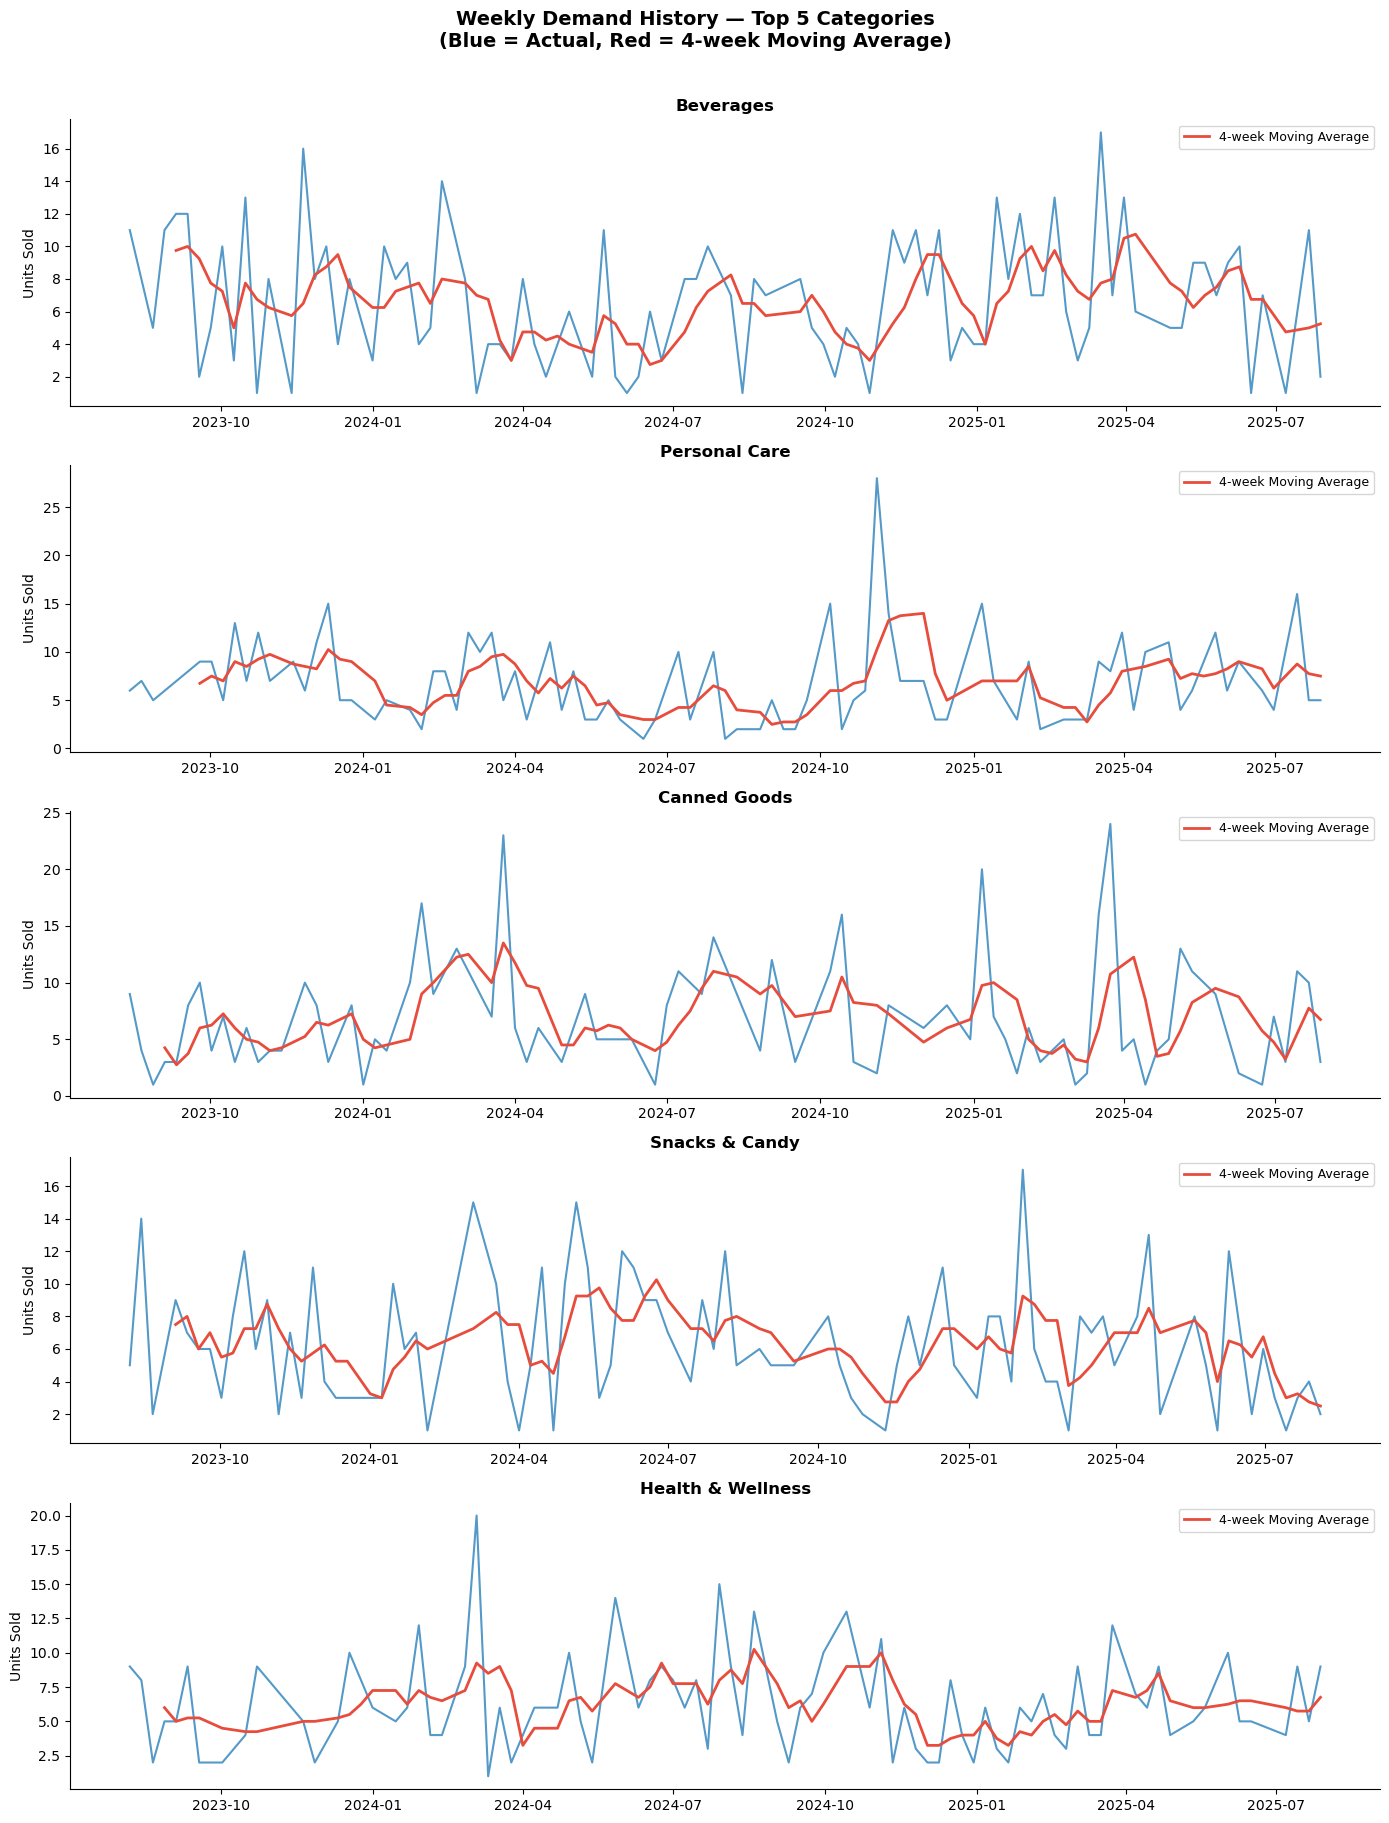

Chart saved!


In [4]:
# Step 3: Plot historical demand for top 5 categories
# Goal: Visualize trends and seasonality before forecasting

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for idx, category in enumerate(top5_categories):
    cat_data = weekly_sales[weekly_sales['category'] == category].sort_values('week_date')
    
    axes[idx].plot(cat_data['week_date'], 
                   cat_data['total_quantity'],
                   color='#2980b9', linewidth=1.5, alpha=0.8)
    
    # Add moving average line
    cat_data['ma4'] = cat_data['total_quantity'].rolling(4).mean()
    axes[idx].plot(cat_data['week_date'],
                   cat_data['ma4'],
                   color='#e74c3c', linewidth=2,
                   label='4-week Moving Average')
    
    axes[idx].set_title(f'{category}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Units Sold', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.suptitle('Weekly Demand History — Top 5 Categories\n(Blue = Actual, Red = 4-week Moving Average)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('outputs/charts/Q5_demand_history_top5.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [5]:
# Step 4: Moving Average Forecast — next 4 weeks
# Method: 4-week moving average of last available data
# Simple, interpretable, widely used by demand planners

forecast_results = []

for category in top5_categories:
    cat_data = weekly_sales[weekly_sales['category'] == category].sort_values('week_date')
    
    # Calculate 4-week moving average forecast
    last_4_weeks = cat_data['total_quantity'].tail(4).values
    ma_forecast = round(last_4_weeks.mean(), 1)
    
    # Get last date for reference
    last_date = cat_data['week_date'].max()
    
    forecast_results.append({
        'category': category,
        'avg_historical_demand': round(cat_data['total_quantity'].mean(), 1),
        'ma_forecast_weekly': ma_forecast,
        'last_4_weeks_avg': ma_forecast,
        'last_date': last_date
    })

forecast_df = pd.DataFrame(forecast_results)

print("=== MOVING AVERAGE FORECAST — NEXT 4 WEEKS ===")
print(forecast_df[['category', 'avg_historical_demand', 'ma_forecast_weekly']].to_string(index=False))

=== MOVING AVERAGE FORECAST — NEXT 4 WEEKS ===
         category  avg_historical_demand  ma_forecast_weekly
        Beverages                    6.7                 5.2
    Personal Care                    6.9                 7.5
     Canned Goods                    6.9                 6.8
   Snacks & Candy                    6.3                 2.5
Health & Wellness                    6.3                 6.8


In [6]:
# Step 5: Exponential Smoothing Forecast — next 4 weeks
# Method: SimpleExpSmoothing from statsmodels
# Gives more weight to recent data — better for volatile demand

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

exp_forecasts = []

for category in top5_categories:
    cat_data = weekly_sales[weekly_sales['category'] == category].sort_values('week_date')
    
    # Fit exponential smoothing model
    model = SimpleExpSmoothing(cat_data['total_quantity'].values)
    fit = model.fit(optimized=True)
    
    # Forecast next 4 weeks
    forecast_4weeks = fit.forecast(4)
    exp_forecast_weekly = round(forecast_4weeks.mean(), 1)
    
    exp_forecasts.append({
        'category': category,
        'exp_forecast_weekly': exp_forecast_weekly,
        'alpha': round(fit.params['smoothing_level'], 3)
    })

exp_df = pd.DataFrame(exp_forecasts)

# Combine with moving average results
combined = forecast_df.merge(exp_df, on='category')

print("=== FORECAST COMPARISON — MA vs EXPONENTIAL SMOOTHING ===")
print(combined[['category', 'avg_historical_demand', 
                'ma_forecast_weekly', 'exp_forecast_weekly', 'alpha']].to_string(index=False))

=== FORECAST COMPARISON — MA vs EXPONENTIAL SMOOTHING ===
         category  avg_historical_demand  ma_forecast_weekly  exp_forecast_weekly  alpha
        Beverages                    6.7                 5.2                  6.5  0.119
    Personal Care                    6.9                 7.5                  6.6  0.013
     Canned Goods                    6.9                 6.8                  7.0  0.036
   Snacks & Candy                    6.3                 2.5                  5.5  0.045
Health & Wellness                    6.3                 6.8                  6.3  0.088


In [7]:
# Step 6: Calculate forecast accuracy metrics
# MAE = Mean Absolute Error — average error in units
# MAPE = Mean Absolute Percentage Error — average error in %
# Lower = better accuracy

mae_results = []

for category in top5_categories:
    cat_data = weekly_sales[weekly_sales['category'] == category].sort_values('week_date')
    
    actual = cat_data['total_quantity'].values
    
    # Moving Average — use rolling 4-week as prediction for each point
    ma_pred = pd.Series(actual).rolling(4).mean().bfill().values
    
    # Exponential Smoothing — fitted values
    model = SimpleExpSmoothing(actual)
    fit = model.fit(optimized=True)
    exp_pred = fit.fittedvalues
    
    # Calculate MAE
    mae_ma = round(np.mean(np.abs(actual - ma_pred)), 2)
    mae_exp = round(np.mean(np.abs(actual - exp_pred)), 2)
    
    # Calculate MAPE
    mape_ma = round(np.mean(np.abs((actual - ma_pred) / (actual + 0.001))) * 100, 1)
    mape_exp = round(np.mean(np.abs((actual - exp_pred) / (actual + 0.001))) * 100, 1)
    
    mae_results.append({
        'category': category,
        'MAE_MovingAvg': mae_ma,
        'MAE_ExpSmoothing': mae_exp,
        'MAPE_MovingAvg': mape_ma,
        'MAPE_ExpSmoothing': mape_exp,
        'better_model': 'Exp Smoothing' if mae_exp < mae_ma else 'Moving Average'
    })

accuracy_df = pd.DataFrame(mae_results)

print("=== FORECAST ACCURACY — MAE & MAPE ===")
print(accuracy_df.to_string(index=False))

=== FORECAST ACCURACY — MAE & MAPE ===
         category  MAE_MovingAvg  MAE_ExpSmoothing  MAPE_MovingAvg  MAPE_ExpSmoothing   better_model
        Beverages           2.72              3.21            82.7              107.5 Moving Average
    Personal Care           2.75              3.31            54.4               71.6 Moving Average
     Canned Goods           3.19              3.96            80.9              114.3 Moving Average
   Snacks & Candy           2.60              3.06            72.3               90.3 Moving Average
Health & Wellness           2.30              2.85            56.3               74.2 Moving Average


/var/folders/pf/hppjmbwj5xq9v6c6jhszd04r0000gn/T/ipykernel_48139/105519072.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ma_pred = pd.Series(actual).rolling(4).mean().fillna(method='bfill').values
/var/folders/pf/hppjmbwj5xq9v6c6jhszd04r0000gn/T/ipykernel_48139/105519072.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ma_pred = pd.Series(actual).rolling(4).mean().fillna(method='bfill').values
/var/folders/pf/hppjmbwj5xq9v6c6jhszd04r0000gn/T/ipykernel_48139/105519072.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ma_pred = pd.Series(actual).rolling(4).mean().fillna(method='bfill').values
/var/folders/pf/hppjmbwj5xq9v6c6jhszd04r0000gn/T/ipykernel_48139/105519072.py:14: FutureWarning: Series.fillna with 'meth

In [8]:
# Step 7: Final Risk Summary Table
# Combines forecast with current inventory data
# This is the key deliverable for Power BI dashboard

inventory = pd.read_csv('data/processed/inventory_clean.csv')

# Get current stock by category
current_stock = inventory.groupby('Category').agg(
    total_stock=('Stock_Quantity', 'sum'),
    avg_days_of_supply=('days_of_supply', 'mean')
).round(1).reset_index()

# Map inventory categories to sales categories where possible
category_map = {
    'Beverages': 'Beverages',
    'Personal Care': 'Personal Care',
    'Canned Goods': 'Canned Goods',
    'Snacks & Candy': 'Snacks & Candy',
    'Health & Wellness': 'Health & Wellness'
}

# Build final summary table
final_summary = combined[['category', 'avg_historical_demand', 
                           'ma_forecast_weekly', 'exp_forecast_weekly']].copy()

final_summary['recommended_forecast'] = final_summary['ma_forecast_weekly']

# Add risk level based on forecast vs historical
def demand_risk(row):
    pct_change = (row['ma_forecast_weekly'] - row['avg_historical_demand']) / row['avg_historical_demand'] * 100
    if pct_change < -20:
        return 'HIGH — Demand Drop'
    elif pct_change > 20:
        return 'HIGH — Demand Spike'
    else:
        return 'STABLE'

final_summary['demand_risk'] = final_summary.apply(demand_risk, axis=1)

print("=== FINAL DEMAND FORECAST SUMMARY TABLE ===")
print(final_summary.to_string(index=False))

# Export for Power BI
final_summary.to_csv('data/processed/forecast_summary.csv', index=False)
print("\nForecast summary exported!")

=== FINAL DEMAND FORECAST SUMMARY TABLE ===
         category  avg_historical_demand  ma_forecast_weekly  exp_forecast_weekly  recommended_forecast        demand_risk
        Beverages                    6.7                 5.2                  6.5                   5.2 HIGH — Demand Drop
    Personal Care                    6.9                 7.5                  6.6                   7.5             STABLE
     Canned Goods                    6.9                 6.8                  7.0                   6.8             STABLE
   Snacks & Candy                    6.3                 2.5                  5.5                   2.5 HIGH — Demand Drop
Health & Wellness                    6.3                 6.8                  6.3                   6.8             STABLE

Forecast summary exported!


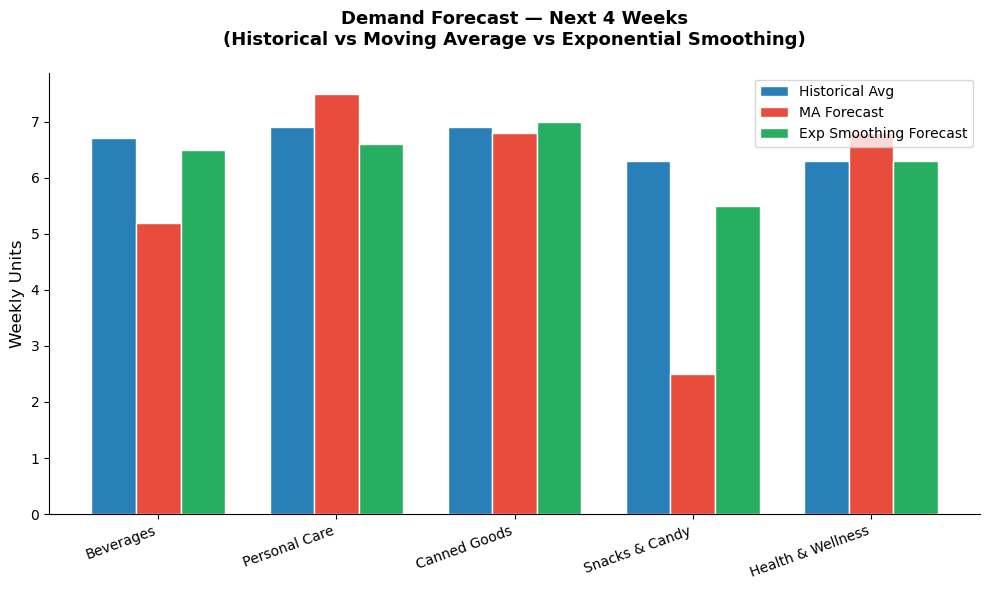

Chart saved!


In [9]:
# Step 8: Final forecast visualization

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(final_summary))
width = 0.25

bars1 = ax.bar([i - width for i in x],
               final_summary['avg_historical_demand'],
               width, label='Historical Avg', color='#2980b9', edgecolor='white')

bars2 = ax.bar([i for i in x],
               final_summary['ma_forecast_weekly'],
               width, label='MA Forecast', color='#e74c3c', edgecolor='white')

bars3 = ax.bar([i + width for i in x],
               final_summary['exp_forecast_weekly'],
               width, label='Exp Smoothing Forecast', color='#27ae60', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(final_summary['category'], rotation=20, ha='right')
ax.set_title('Demand Forecast — Next 4 Weeks\n(Historical vs Moving Average vs Exponential Smoothing)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Weekly Units', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/charts/Q5_demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")